# Wine Quality Prediction — Beginner & Business Friendly ML Project

**Creator: Phyo Thaw**

---

## Project Purpose

This notebook predicts whether a wine is likely to be **good quality** or **lower quality** using machine learning.

It is designed for two audiences:

1. **Students learning AI/ML**  
   The notebook explains the workflow step by step using beginner-friendly language.

2. **Employers looking for data-driven product thinking**  
   The notebook connects technical results with product quality, business decisions, and quality assurance.

---

## Business Problem

Wine quality depends on many chemical properties such as alcohol, acidity, sulphates, density, and pH.

For a wine producer or product team, data analysis can help answer questions such as:

- Which chemical properties are associated with better wine quality?
- Can machine learning support wine quality classification?
- Which features should quality control teams monitor more closely?
- How can analytics support product consistency and improvement?

---

## Machine Learning Problem

This is a **binary classification problem**.

The original `quality` score is converted into:

- `1 = Good Wine`
- `0 = Lower Quality Wine`

For this project:

- quality >= 6 → Good Wine
- quality < 6 → Lower Quality Wine

# 1. Import Required Libraries

We import libraries for:

- data handling
- visualization
- preprocessing
- model training
- model evaluation
- feature selection

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# 2. Load Dataset

This notebook assumes your dataset file is named:

```python
WineQT.csv
```

and stored in the same folder as this notebook.

If you use Kaggle, upload the dataset and update the path if needed.

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/wine-quality-dataset",
    "WineQT.csv"
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# 3. Basic Dataset Understanding

Before modeling, we check:

- dataset size
- data types
- missing values
- summary statistics

This is important because machine learning models depend heavily on data quality.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [5]:
missing_values = df.isnull().sum()
missing_values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## Beginner Note

If all missing values are zero, it means pandas does not detect empty values.

However, we should still check whether the dataset contains:

- duplicated rows
- unnecessary ID columns
- unusual values

In [6]:
print("Duplicated rows:", df.duplicated().sum())

# Some WineQT datasets include an Id column.
# It is not useful for prediction, so we remove it if it exists.
if "Id" in df.columns:
    df = df.drop(columns=["Id"])
    print("Id column removed.")

df.head()

Duplicated rows: 0
Id column removed.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


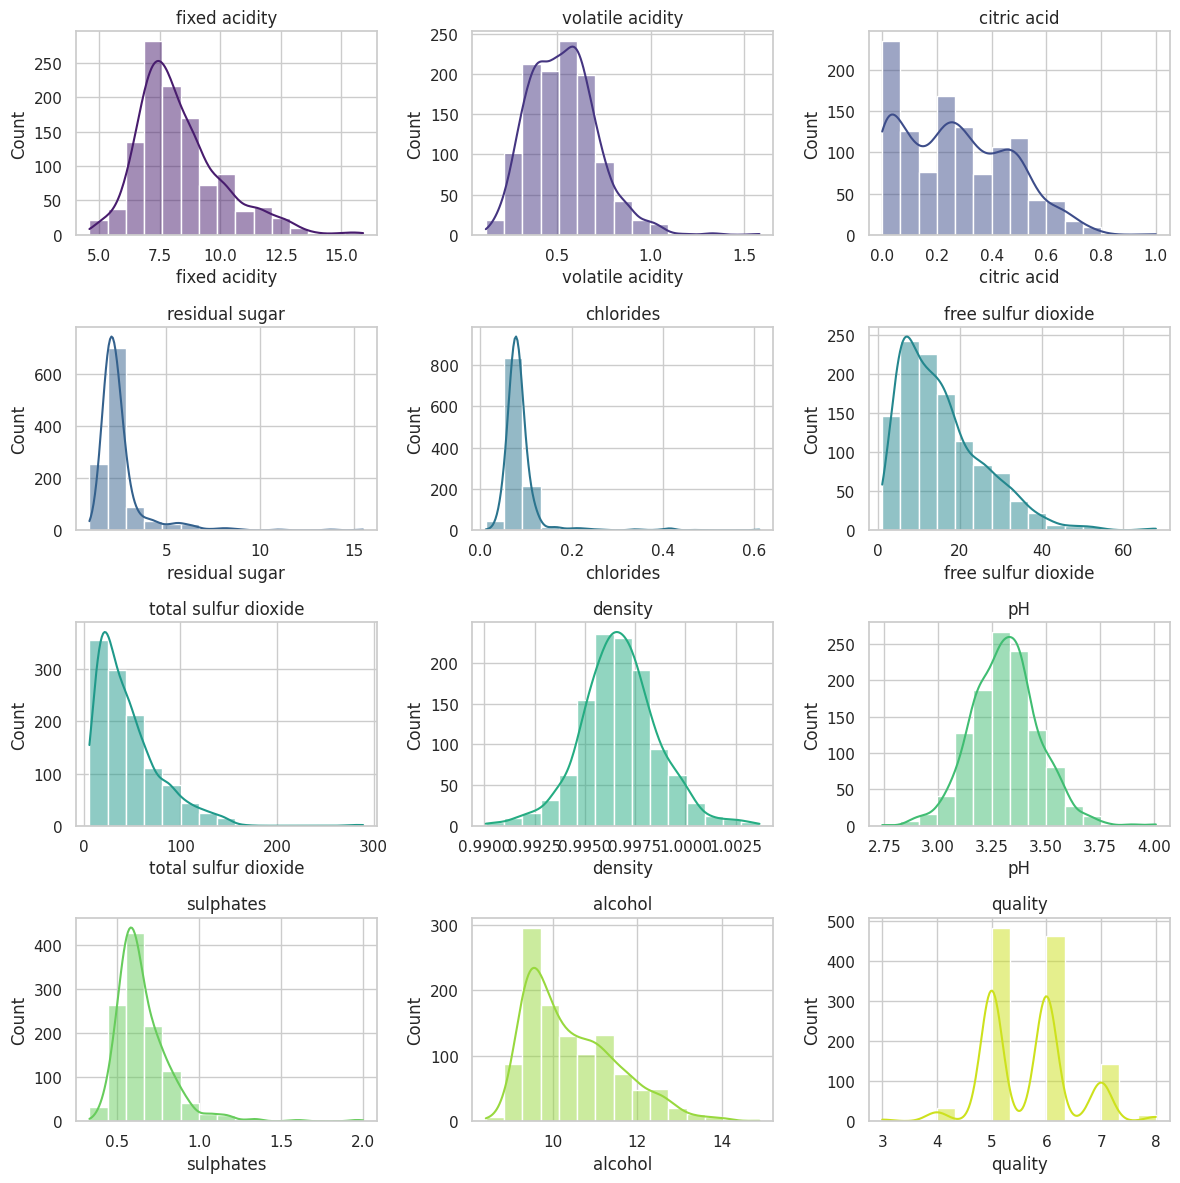

Skewness of each column:
fixed acidity: 1.0449299563724053
volatile acidity: 0.6815474143781255
citric acid: 0.3715607833706083
residual sugar: 4.361096404323471
chlorides: 6.026360154399587
free sulfur dioxide: 1.2312611567075427
total sulfur dioxide: 1.6657660141342994
density: 0.102395108720599
pH: 0.22113839209685748
sulphates: 2.497266051332364
alcohol: 0.8633132317223615
quality: 0.2867917004538591


In [7]:
import math
import seaborn as sb
import matplotlib.pyplot as plt
cols = df.columns
colors = sb.color_palette("viridis", len(cols))

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(12, n_rows * 3))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sb.histplot(df[col], bins=15, color=colors[i], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()
print("Skewness of each column:")
for col in cols:
    print(f"{col}: {df[col].skew()}")


# 4. Create Target Variable

The original target column is `quality`.

We convert it into a simpler binary classification target:

- `good_wine = 1` if quality is 6 or higher
- `good_wine = 0` if quality is below 6

This makes the project easier for beginners and more practical for business interpretation.

In [8]:
df["good_wine"] = np.where(df["quality"] >= 6, 1, 0)
df[["quality", "good_wine"]].head()

,quality,good_wine
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0


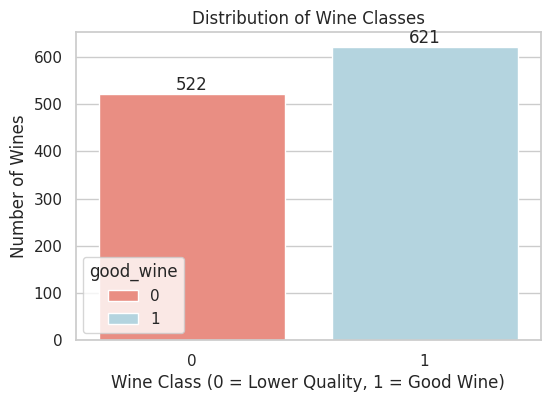

good_wine
1    0.543307
0    0.456693
Name: proportion, dtype: float64

In [9]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="good_wine", hue="good_wine", palette=["salmon", "lightblue"], dodge=False)

plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class (0 = Lower Quality, 1 = Good Wine)")
plt.ylabel("Number of Wines")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

df["good_wine"].value_counts(normalize=True)

## Class Balance Interpretation

The target distribution helps us understand whether the dataset is balanced.

If one class is much larger than the other, accuracy alone may be misleading.

That is why this notebook uses several metrics:

- accuracy
- precision
- recall
- F1-score
- ROC-AUC

# 5. Exploratory Data Analysis

EDA helps us understand the data before applying machine learning.

Instead of only making many plots, each visualization should help answer a question.

## 5.1 Quality Score Distribution

**Question:** What quality scores are most common in the dataset?

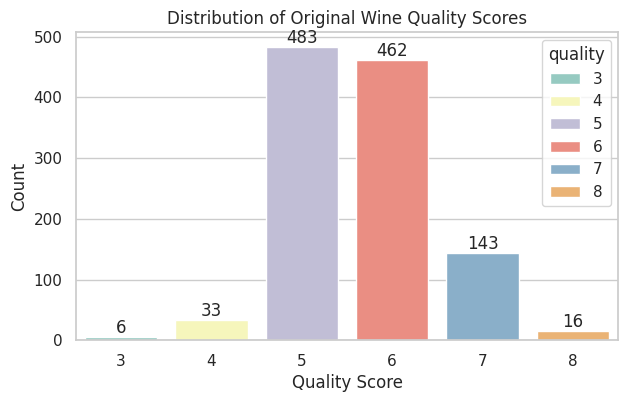

In [10]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(data=df, x="quality", palette="Set3", order=sorted(df["quality"].unique()), hue="quality", dodge=False)
plt.title("Distribution of Original Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)
plt.show()

## 5.2 Alcohol and Wine Quality

**Question:** Do better quality wines tend to have higher alcohol content?

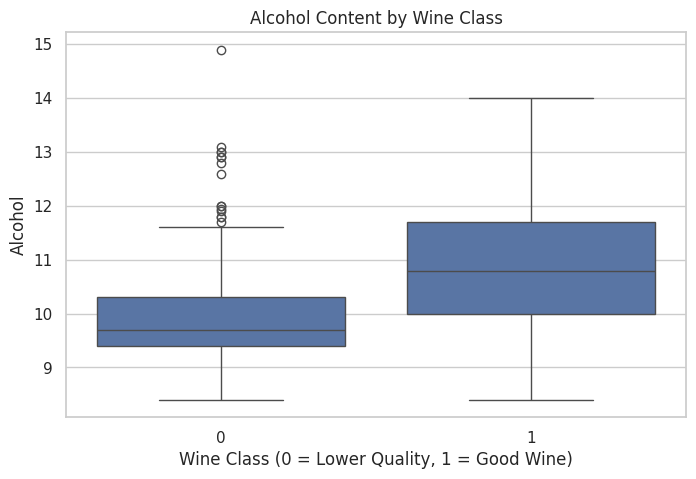

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="good_wine", y="alcohol")

plt.title("Alcohol Content by Wine Class")
plt.xlabel("Wine Class (0 = Lower Quality, 1 = Good Wine)")
plt.ylabel("Alcohol")

plt.show()

## 5.3 Volatile Acidity and Wine Quality

**Question:** Is volatile acidity related to lower quality?

Volatile acidity is important because high values may create unpleasant vinegar-like taste.

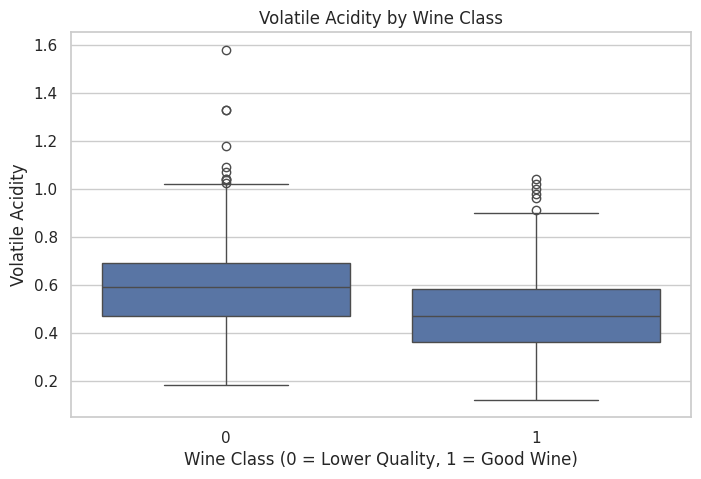

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="good_wine", y="volatile acidity")

plt.title("Volatile Acidity by Wine Class")
plt.xlabel("Wine Class (0 = Lower Quality, 1 = Good Wine)")
plt.ylabel("Volatile Acidity")

plt.show()

## 5.4 Sulphates and Wine Quality

**Question:** Are sulphates associated with better quality classification?

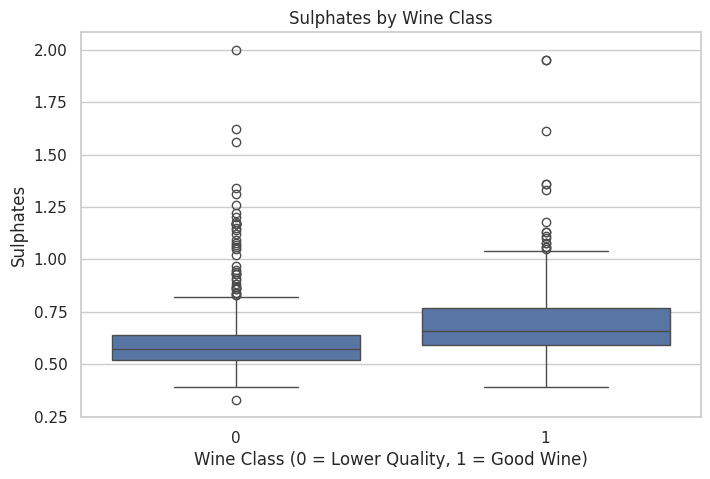

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="good_wine", y="sulphates")

plt.title("Sulphates by Wine Class")
plt.xlabel("Wine Class (0 = Lower Quality, 1 = Good Wine)")
plt.ylabel("Sulphates")

plt.show()

## 5.5 Correlation Heatmap

**Question:** Which numeric variables are strongly related to each other and to wine quality?

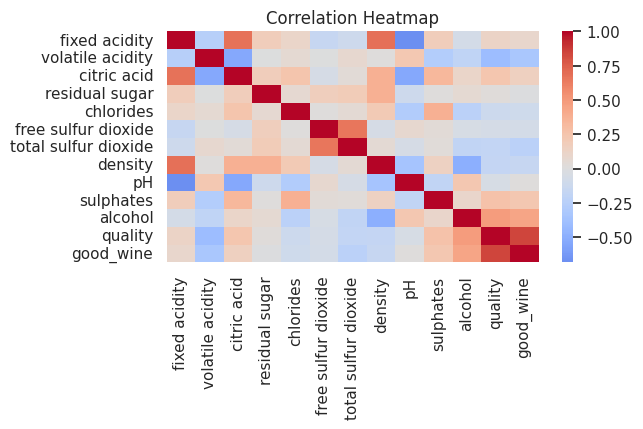

In [14]:
plt.figure(figsize=(6, 3))

corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
quality_corr = corr["quality"].sort_values(ascending=False)
quality_corr

quality                 1.000000
good_wine               0.846007
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

## EDA Summary

Typical patterns in wine quality data may include:

- alcohol often has a positive relationship with quality
- volatile acidity often has a negative relationship with quality
- sulphates may be useful for classification
- some features are correlated with each other

From a business perspective, this helps quality teams understand which chemical indicators may deserve closer monitoring.

# 6. Feature and Target Preparation

This section prepares the input features and target variable.

Important note:

This is not feature selection yet.  
This is simply separating `X` and `y`.

Feature selection is tested later in a separate experiment.

In [16]:
X = df.drop(columns=["quality", "good_wine"])
y = df["good_wine"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (1143, 11)
Target shape: (1143,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


# 7. Train-Test Split

We split the dataset into:

- training set: used for model training and cross-validation
- test set: used only once for final evaluation

We use `stratify=y` so that both sets have similar class distributions.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (857, 11)
Test set: (286, 11)

Training target distribution:
good_wine
1    0.543757
0    0.456243
Name: proportion, dtype: float64

Test target distribution:
good_wine
1    0.541958
0    0.458042
Name: proportion, dtype: float64


# 8. Model Comparison with Cross-Validation

This section compares models using the **same feature set** and **same evaluation method**.

We use pipelines so scaling happens correctly inside cross-validation.

This avoids data leakage and keeps the workflow clean.

Models compared:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine

Scalers compared:

1. StandardScaler
2. MinMaxScaler

Why compare scalers?

- Logistic Regression and SVM are sensitive to scaling.
- Random Forest usually does not require scaling, but keeping the pipeline consistent is okay for comparison.

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE)
}

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results = []

for scaler_name, scaler in scalers.items():

    for model_name, model in models.items():

        pipeline = Pipeline(steps=[
            ("scaler", scaler),
            ("model", model)
        ])

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring
        )

        results.append({
            "Experiment": "All Features",
            "Scaler": scaler_name,
            "Model": model_name,
            "Accuracy": scores["test_accuracy"].mean(),
            "Precision": scores["test_precision"].mean(),
            "Recall": scores["test_recall"].mean(),
            "F1-score": scores["test_f1"].mean(),
            "ROC-AUC": scores["test_roc_auc"].mean()
        })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    color="lightgreen"
)

,Experiment,Scaler,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,All Features,MinMaxScaler,Random Forest,0.781817,0.796596,0.804804,0.800336,0.855221
1,All Features,StandardScaler,Random Forest,0.780641,0.797306,0.800503,0.798689,0.853747
2,All Features,StandardScaler,SVM,0.757337,0.771164,0.787737,0.778677,0.837571
5,All Features,MinMaxScaler,SVM,0.766646,0.784083,0.787692,0.785576,0.833523
3,All Features,MinMaxScaler,Logistic Regression,0.747940,0.767776,0.770442,0.768726,0.815320
0,All Features,StandardScaler,Logistic Regression,0.749082,0.765858,0.776893,0.771082,0.814333


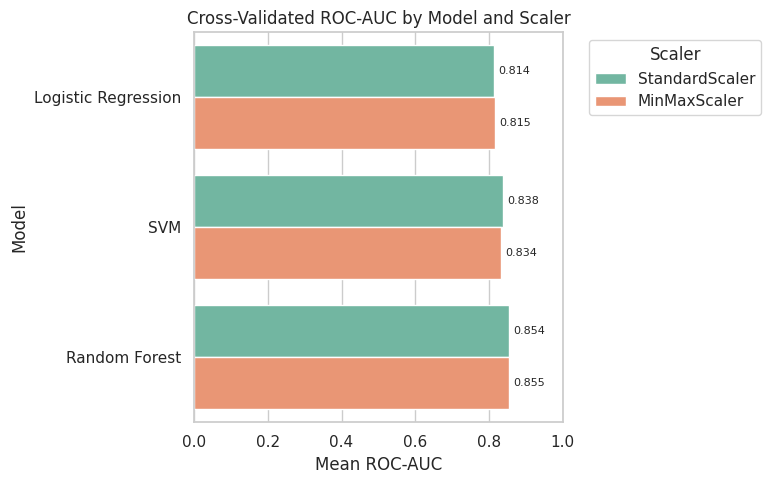

In [19]:
plot_df = results_df.sort_values("ROC-AUC")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="ROC-AUC",
    y="Model",
    hue="Scaler",
    palette="Set2"
)

plt.title("Cross-Validated ROC-AUC by Model and Scaler")
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Model")
plt.xlim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.legend(title="Scaler", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Model Comparison Interpretation

This table and chart show cross-validated performance on the training data.

These results should be used to compare models fairly.

However, they are not the final test results.

The final evaluation will be done later using the unseen test set.

# 9. Feature Selection Experiment

Now we test whether using fewer features improves performance.

We use `SelectKBest` to select the top features based on statistical relationship with the target.

Important:

This is an experiment.  
The result may be better or worse than using all features.

We keep this section separate so there is no contradiction with the final model evaluation.

In [20]:
k_values = [3, 5, 7, "all"]

feature_selection_results = []

for k in k_values:

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k)),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE))
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    feature_selection_results.append({
        "Experiment": "Feature Selection",
        "Selected Features": k,
        "Scaler": "StandardScaler",
        "Model": "Random Forest",
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

feature_selection_df = pd.DataFrame(feature_selection_results).sort_values("ROC-AUC", ascending=False)
feature_selection_df

,Experiment,Selected Features,Scaler,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Feature Selection,all,StandardScaler,Random Forest,0.780641,0.797306,0.800503,0.798689,0.853747
2,Feature Selection,7,StandardScaler,Random Forest,0.772467,0.784088,0.802608,0.793166,0.851644
1,Feature Selection,5,StandardScaler,Random Forest,0.778295,0.800845,0.789774,0.794817,0.849053
0,Feature Selection,3,StandardScaler,Random Forest,0.740929,0.758471,0.770373,0.764076,0.819748


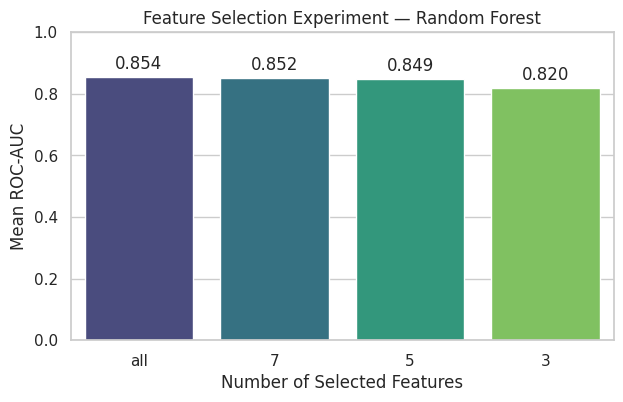

In [21]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=feature_selection_df,
    x="Selected Features",
    y="ROC-AUC",
    hue="Selected Features",
    palette="viridis",
    legend=False
)

plt.title("Feature Selection Experiment — Random Forest")
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean ROC-AUC")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.show()

## Feature Selection Interpretation

If fewer features perform similarly to all features, it may be useful to simplify the model.

A simpler model can be easier to explain to business stakeholders.

However, if all features perform better, keeping all features may be reasonable.

In this notebook, the final model will be chosen clearly based on cross-validation results and practical interpretability.

# 10. Final Model Choice

To avoid confusion, we make a clear decision.

For the final model, we will use:

- Random Forest
- StandardScaler pipeline
- all original features
- hyperparameter tuning with GridSearchCV

Why Random Forest?

- It usually performs well on tabular data.
- It can capture nonlinear relationships.
- It provides feature importance, which is useful for business interpretation.

Important:

Even if another model has a slightly higher cross-validation score, Random Forest is selected here because this project is focused on both prediction and interpretation.

# 11. Hyperparameter Tuning

We tune Random Forest using cross-validation.

Hyperparameters tested:

- `n_estimators`: number of trees
- `max_depth`: maximum tree depth
- `min_samples_leaf`: minimum samples in leaf nodes

In [22]:
final_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    final_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validated ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Best cross-validated ROC-AUC:
0.8579841551799277


# 12. Final Evaluation on Unseen Test Set

Now we evaluate the tuned model on the test set.

This is the final performance result.

Do not compare this result directly with cross-validation scores as if they are the same thing.

- Cross-validation score = average training-fold performance
- Test score = performance on one unseen holdout test set

Small differences are expected.

In [23]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "Model": "Tuned Random Forest",
    "Features": "All Features",
    "Scaler": "StandardScaler",
    "Evaluation Method": "Holdout Test Set",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    color="lightgreen"
)

,Model,Features,Scaler,Evaluation Method,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Random Forest,All Features,StandardScaler,Holdout Test Set,0.776224,0.772455,0.832258,0.801242,0.869934


In [24]:
print(classification_report(y_test, y_pred, target_names=["Lower Quality", "Good Wine"]))

               precision    recall  f1-score   support

Lower Quality       0.78      0.71      0.74       131
    Good Wine       0.77      0.83      0.80       155

     accuracy                           0.78       286
    macro avg       0.78      0.77      0.77       286
 weighted avg       0.78      0.78      0.78       286



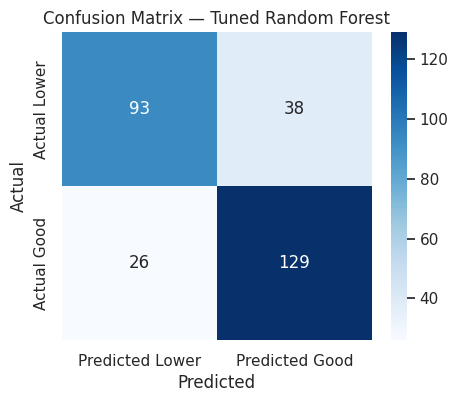

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Lower", "Predicted Good"],
    yticklabels=["Actual Lower", "Actual Good"]
)
plt.title("Confusion Matrix — Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

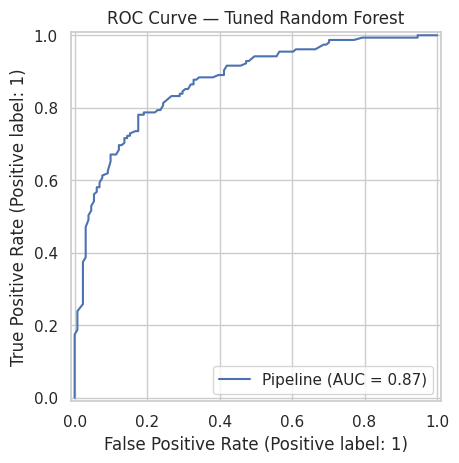

In [26]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("ROC Curve — Tuned Random Forest")
plt.show()

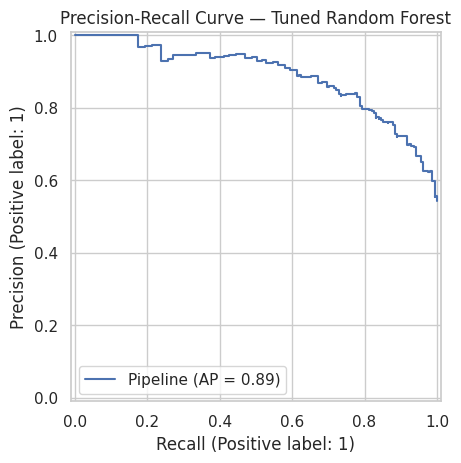

In [27]:
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)

plt.title("Precision-Recall Curve — Tuned Random Forest")
plt.show()

## Final Evaluation Interpretation

The final test result shows how the tuned model performs on unseen data.

For a business or product team:

- high precision means predicted good wines are more likely to truly be good
- high recall means the model captures more actual good wines
- ROC-AUC shows how well the model separates good and lower quality wines overall

The best metric depends on the business goal.

For example:

- if the company wants to avoid promoting lower quality wine as good, precision matters more
- if the company wants to identify as many good wines as possible, recall matters more

# 13. Feature Importance

Random Forest provides feature importance values.

This helps explain which wine characteristics contributed most to the model prediction.

Important:

Feature importance does not prove causation.  
It only shows which features were useful for prediction.

In [28]:
rf_model = best_model.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
10,alcohol,0.198560
9,sulphates,0.138370
6,total sulfur dioxide,0.107022
1,volatile acidity,0.094300
7,density,0.078920
4,chlorides,0.072689
8,pH,0.070980
0,fixed acidity,0.067433
2,citric acid,0.061130
5,free sulfur dioxide,0.057294


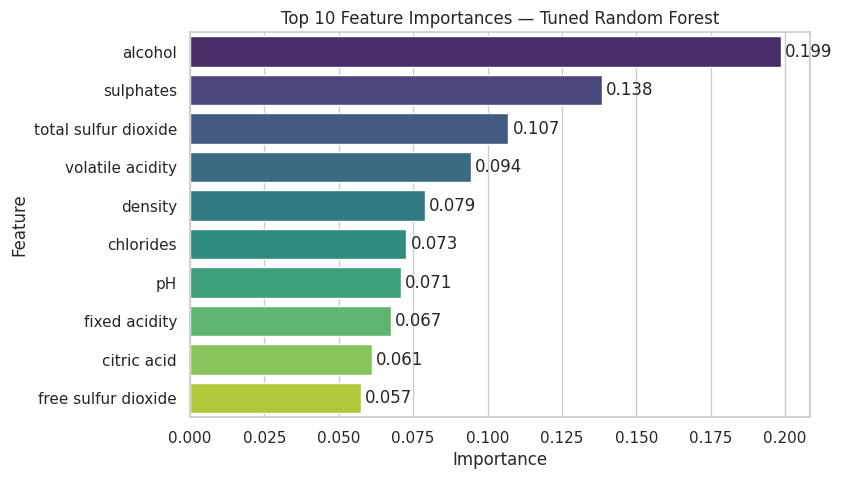

In [29]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("Top 10 Feature Importances — Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.show()

## Business Interpretation of Feature Importance

If features such as alcohol, sulphates, volatile acidity, or density appear important, this can help product and quality teams focus on key measurable indicators.

Possible business uses:

- support quality assurance checks
- monitor production consistency
- identify chemical properties linked with customer-perceived quality
- guide further experiments in wine production

However, these findings should be validated with domain experts before making production decisions.

# 14. Business Recommendations

Based on the analysis, a wine producer or product team could consider:

| Insight Area | Business Recommendation |
|---|---|
| Alcohol level | Monitor alcohol range as a potential quality indicator |
| Volatile acidity | Investigate high volatile acidity because it may reduce perceived quality |
| Sulphates | Track sulphate levels as part of quality control |
| Model prediction | Use ML as a decision-support tool, not as a replacement for wine experts |
| Quality assurance | Combine chemical tests with expert tasting results |

This is where data science connects with product decision-making.

# 15. Limitations

This project has several limitations:

1. **Small dataset**  
   The dataset may not represent all wines or production environments.

2. **Subjective quality ratings**  
   Wine quality scores are based on human evaluation and may contain subjectivity.

3. **No production context**  
   The dataset does not include region, grape type, storage conditions, brand, or price.

4. **Correlation, not causation**  
   The model identifies patterns, but it does not prove that a feature causes higher quality.

5. **Binary simplification**  
   Converting quality into good/lower quality makes the problem easier, but it loses some detail.

6. **Business validation needed**  
   Model findings should be reviewed with wine production or quality control experts.

# 16. Future Improvements

This project can be upgraded further by:

- predicting exact quality score using regression
- testing XGBoost or LightGBM
- adding SHAP explainability
- creating a Streamlit app
- building a Power BI dashboard
- comparing red and white wine datasets
- using external business data such as price, brand, region, or customer ratings

# 17. Final Conclusion

This project demonstrated a complete beginner-friendly machine learning workflow for wine quality prediction.

The workflow included:

1. business problem framing
2. dataset understanding
3. EDA
4. target creation
5. model comparison
6. feature selection experiment
7. hyperparameter tuning
8. final test evaluation
9. feature importance
10. business recommendations

The most important lesson is that a strong ML project is not only about model scores.

A strong portfolio project should also explain:

- why the problem matters
- how the data was prepared
- what the model results mean
- how insights can support decisions
- what limitations should be considered

This makes the project useful for both students learning ML and employers looking for data-driven product thinking.